# Segmentation Model with Simulated Data

## **Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from logic.segment import (
    build_model,
    run_predictions,
    compute_boundary_errors,
    shade_regions,
    REGION_TO_STATE,
    STATE_TO_REGION,
    REGION_COLORS,
)

db = pd.read_csv('../nanopore_trace_database.csv')
train_db = db[db['trace_id'] < 500]
test_db  = db[db['trace_id'] >= 500]

## **Build HMM**

In [28]:
model = build_model(train_db)

print("means_   (pA) :", model.means_.flatten())
print("covars_  (pA²):", model.covars_.flatten())
print("startprob     :", model.startprob_)
print("transmat      :\n", model.transmat_)

means_   (pA) : [78.90751781 91.57300877]
covars_  (pA²): [216.32128758 193.05495358]
startprob     : [1. 0.]
transmat      :
 [[9.999e-01 1.000e-04]
 [0.000e+00 1.000e+00]]


## **Define Emmission Distributions**

### Visualize how the distributions look, evaluate the difficulty of this problem

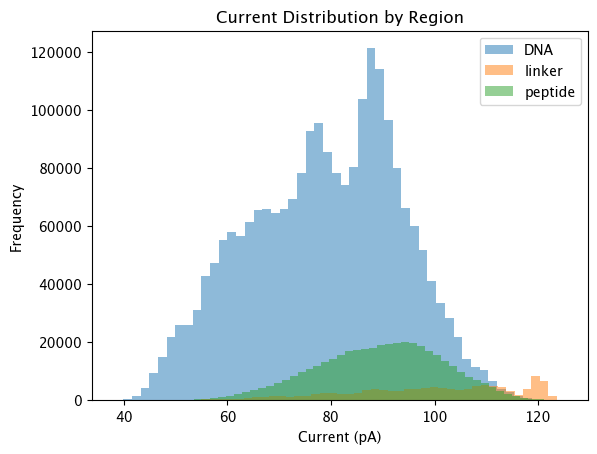

In [29]:
for region in ['DNA', 'linker', 'peptide']:
    subset = db[db['region'] == region]['current_pA']
    plt.hist(subset, bins=50, alpha=0.5, label=region)
    plt.xlabel('Current (pA)')
    plt.ylabel('Frequency')
    plt.title('Current Distribution by Region')
plt.legend()
plt.show()

## **Run Predictions**

In [30]:
accuracies, predictions = run_predictions(model, test_db)

overall_acc = np.mean(list(accuracies.values()))
print(f"Overall accuracy: {overall_acc:.2%}\n")
print(f"{'Trace':>6}  {'Accuracy':>8}")
for tid, acc in sorted(accuracies.items()):
    print(f"  {tid:>6}  {acc:>8.2%}")

Overall accuracy: 90.06%

 Trace  Accuracy
     500    98.56%
     501    52.66%
     502    88.97%
     503    86.36%
     504    97.78%
     505    97.26%
     506    85.93%
     507    97.33%
     508    98.94%
     509    37.10%
     510    99.20%
     511    99.45%
     512    90.56%
     513    80.28%
     514    98.94%
     515    86.20%
     516    95.49%
     517    88.94%
     518    92.61%
     519    98.86%
     520    98.90%
     521    85.44%
     522    84.56%
     523    98.53%
     524    97.78%
     525    97.66%
     526    81.00%
     527    98.04%
     528    32.56%
     529    97.20%
     530    87.99%
     531    97.08%
     532    98.22%
     533    98.91%
     534    98.38%
     535    89.14%
     536    98.65%
     537    91.09%
     538    24.64%
     539    87.74%
     540    91.66%
     541    88.53%
     542    93.10%
     543    98.28%
     544    69.68%
     545    80.18%
     546    98.39%
     547    97.92%
     548    98.71%
     549    95.18%
     55

In [31]:
for tid, acc in sorted(accuracies.items()):
    if acc < 0.9:
        print(f"\nTrace {tid} - Accuracy: {acc:.2%}")


Trace 501 - Accuracy: 52.66%

Trace 502 - Accuracy: 88.97%

Trace 503 - Accuracy: 86.36%

Trace 506 - Accuracy: 85.93%

Trace 509 - Accuracy: 37.10%

Trace 513 - Accuracy: 80.28%

Trace 515 - Accuracy: 86.20%

Trace 517 - Accuracy: 88.94%

Trace 521 - Accuracy: 85.44%

Trace 522 - Accuracy: 84.56%

Trace 526 - Accuracy: 81.00%

Trace 528 - Accuracy: 32.56%

Trace 530 - Accuracy: 87.99%

Trace 535 - Accuracy: 89.14%

Trace 538 - Accuracy: 24.64%

Trace 539 - Accuracy: 87.74%

Trace 541 - Accuracy: 88.53%

Trace 544 - Accuracy: 69.68%

Trace 545 - Accuracy: 80.18%

Trace 551 - Accuracy: 65.27%

Trace 552 - Accuracy: 89.67%

Trace 559 - Accuracy: 77.85%

Trace 574 - Accuracy: 84.01%

Trace 575 - Accuracy: 82.04%

Trace 584 - Accuracy: 84.79%

Trace 587 - Accuracy: 89.98%

Trace 589 - Accuracy: 75.76%

Trace 591 - Accuracy: 21.91%

Trace 594 - Accuracy: 53.59%

Trace 598 - Accuracy: 83.92%


## **Visualize**

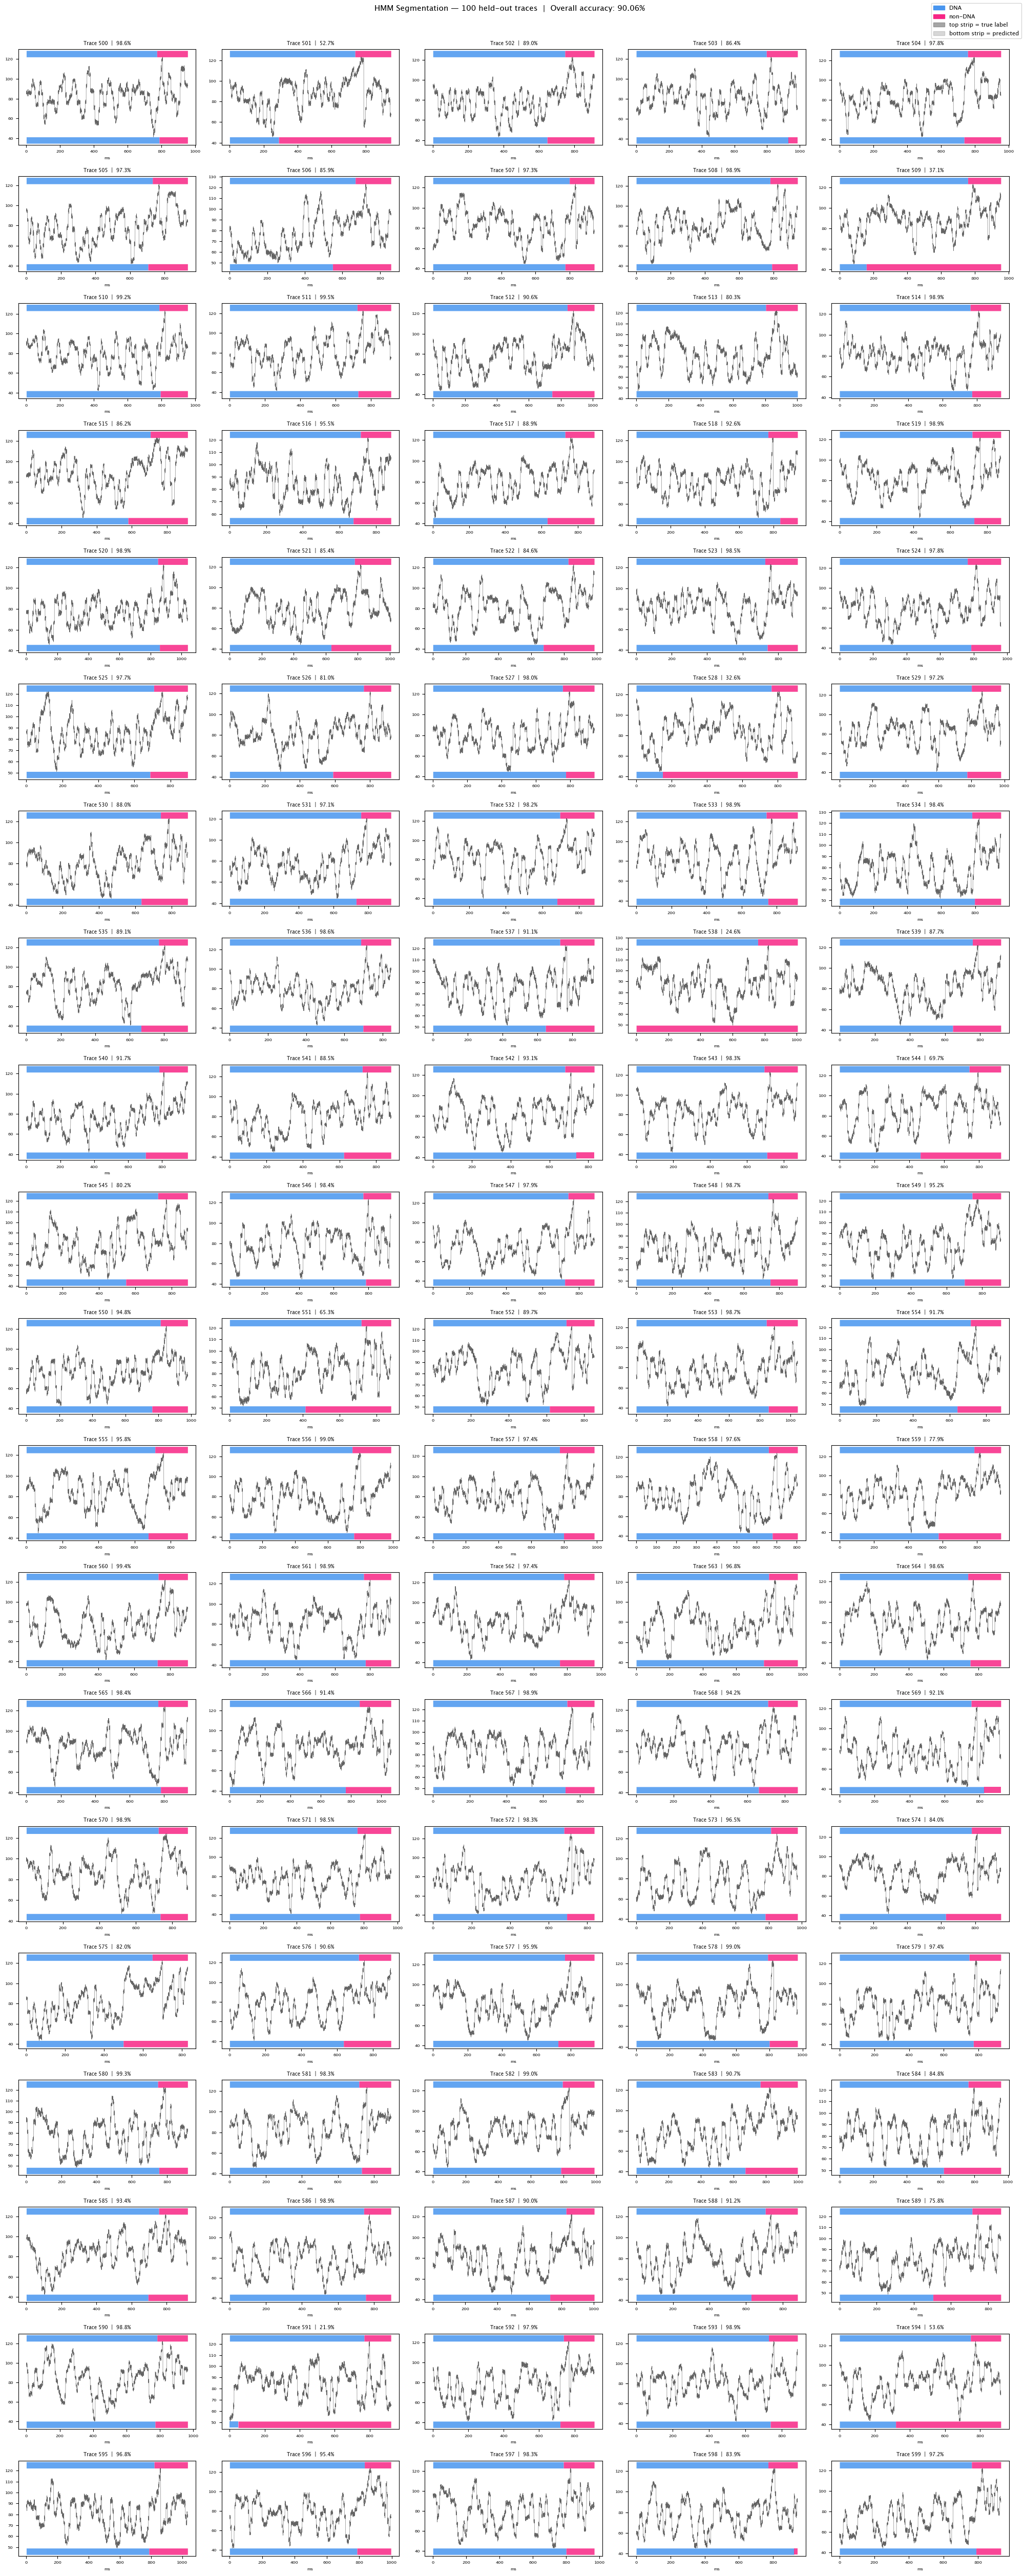

In [32]:
n     = len(predictions)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 2.5), squeeze=False)

for idx, (tid, data) in enumerate(predictions.items()):
    ax = axes[idx // ncols][idx % ncols]
    t, I = data['time_ms'], data['current_pA']

    ymin, ymax = I.min(), I.max()
    band = (ymax - ymin) * 0.08

    shade_regions(ax, t, data['true_states'], ymax,        ymax + band)  # top strip = true
    shade_regions(ax, t, data['pred_states'], ymin - band, ymin)          # bottom strip = predicted

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
    ax.set_title(f'Trace {tid}  |  {accuracies[tid]:.1%}', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('ms', fontsize=6)

for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

legend_patches  = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches += [
    mpatches.Patch(color='gray', alpha=0.7, label='top strip = true label'),
    mpatches.Patch(color='gray', alpha=0.3, label='bottom strip = predicted'),
]
fig.legend(handles=legend_patches, loc='upper right', fontsize=8)
fig.suptitle(f'HMM Segmentation — {n} held-out traces  |  Overall accuracy: {overall_acc:.2%}',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

In [25]:
import ipywidgets as widgets
from IPython.display import display

trace_ids = list(predictions.keys())

def plot_trace(idx):
    plt.close('all')
    tid = trace_ids[idx]
    data = predictions[tid]
    t, I = data['time_ms'], data['current_pA']

    fig, ax = plt.subplots(figsize=(13, 5))

    shade_regions(ax, t, data['true_states'],  244, 250)   # top
    shade_regions(ax, t, data['pred_states'],  0,   6)     # bottom

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(0, 250)
    ax.set_title(f'Trace {tid}  |  Accuracy: {accuracies[tid]:.1%}', fontsize=10)
    ax.set_xlabel('ms')

    legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
    legend_patches += [
        mpatches.Patch(color='gray', alpha=0.7, label='top = true'),
        mpatches.Patch(color='gray', alpha=0.3, label='bottom = predicted'),
    ]
    ax.legend(handles=legend_patches, fontsize=13, loc='upper right')
    plt.tight_layout()
    display(fig)
    plt.close(fig)

widgets.interact(plot_trace, idx=widgets.IntSlider(min=0, max=len(trace_ids)-1, step=1, description='Trace'))


interactive(children=(IntSlider(value=0, description='Trace', max=99), Output()), _dom_classes=('widget-intera…

<function __main__.plot_trace(idx)>

In [ ]:
boundary_errors = compute_boundary_errors(predictions)

errors = np.array(list(boundary_errors.values()))
print(f"Mean boundary error : {errors.mean():.3f} ms")
print(f"Std  boundary error : {errors.std():.3f} ms")
print(f"MAE                 : {np.abs(errors).mean():.3f} ms")
print(f"Max early           : {errors.min():.3f} ms")
print(f"Max late            : {errors.max():.3f} ms")

plt.figure(figsize=(8, 3))
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='perfect boundary')
plt.xlabel('Boundary error (ms)  [+ = predicted late, − = predicted early]')
plt.ylabel('Count')
plt.title('Peptide Start Boundary Detection Error')
plt.legend()
plt.tight_layout()
plt.show()

## Test on Real Fast5 Data

In [39]:
import pathlib
import tomllib
import poreflow as pf

with open("parameters.toml", "rb") as f:
    config = tomllib.load(f)

input_cfg = config["input"]
data_path = pathlib.Path(input_cfg["path"]) / input_cfg["file"]
target_sfreq = input_cfg["target_SamplingRate"]

CHANNEL = 18   # change to your channel of interest
EVENT_IDX = 20  # index into events found in this channel

with pf.File(data_path) as f:
    raw = f.get_raw(CHANNEL, downsample=target_sfreq)

events = raw.find_events(**config["event_finding"])
if events is None or len(events) == 0:
    raise RuntimeError(f"No events found in channel {CHANNEL}")
events = events.filter_by_duration()
print(f"Found {len(events)} events in channel {CHANNEL}")

ev = events.iloc[EVENT_IDX]
event_current = raw['i'].values[int(ev['start_idx']):int(ev['end_idx'])]
event_ios     = float(ev['ios'])

print(f"Event {EVENT_IDX}: {len(event_current)} samples | IOS = {event_ios:.1f} pA")
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")

Found 152 events in channel 18
Event 20: 8031 samples | IOS = 256.3 pA
Current range: 8.7 – 248.3 pA


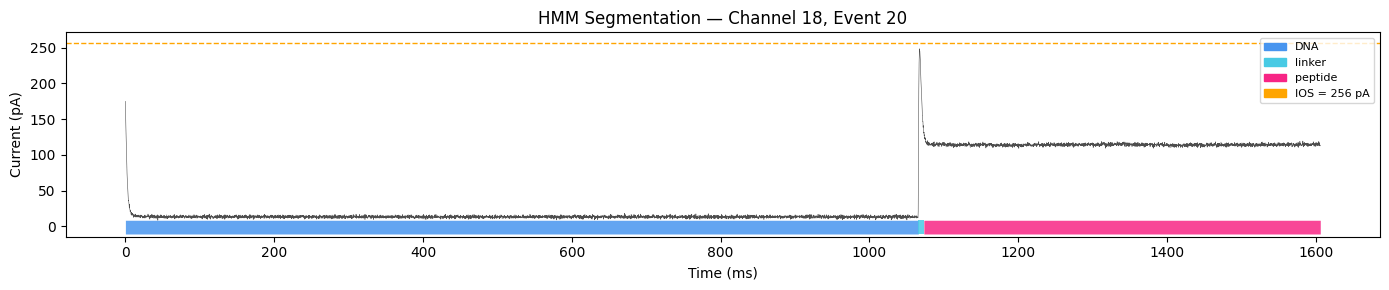

Predicted region fractions:
       DNA: 66.4%
    linker: 0.4%
   peptide: 33.2%


In [17]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

X = event_current.reshape(-1, 1)
pred_states = model.predict(X)

fig, ax = plt.subplots(figsize=(14, 3))
ymin, ymax = event_current.min(), event_current.max()
band = (ymax - ymin) * 0.08

shade_regions(ax, t_ms, pred_states, ymin - band, ymin)
ax.plot(t_ms, event_current, color='#222', lw=0.4, alpha=0.8)
ax.axhline(event_ios, color='orange', linestyle='--', lw=1, label=f'IOS = {event_ios:.0f} pA')

ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Current (pA)')
ax.set_title(f'HMM Segmentation — Channel {CHANNEL}, Event {EVENT_IDX}')

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color='orange', label=f'IOS = {event_ios:.0f} pA'))
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print("Predicted region fractions:")
for state, region in STATE_TO_REGION.items():
    print(f"  {region:>8}: {np.mean(pred_states == state):.1%}")

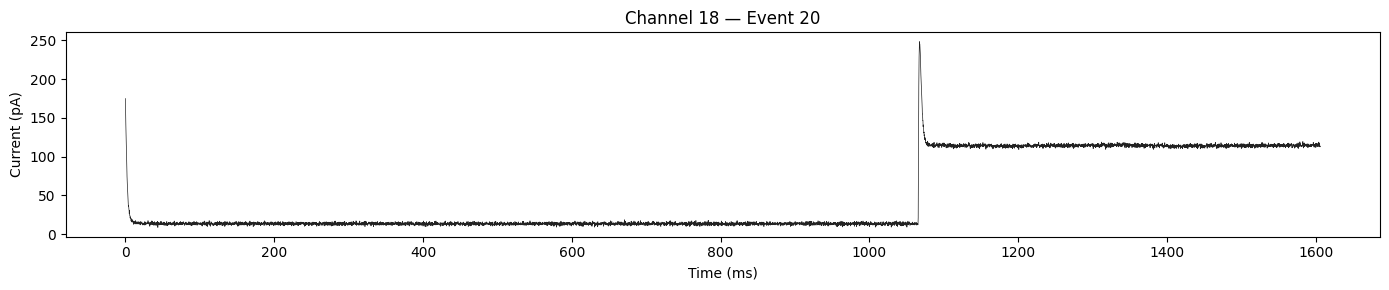

In [18]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

plt.figure(figsize=(14, 3))
plt.plot(t_ms, event_current, lw=0.5, color='#222')
plt.xlabel('Time (ms)')
plt.ylabel('Current (pA)')
plt.title(f'Channel {CHANNEL} — Event {EVENT_IDX}')
plt.tight_layout()
plt.show()

In [22]:
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")
print(f"Event duration: {len(event_current) / target_sfreq:.2f} s")
print(f"IOS: {event_ios:.1f} pA")

Current range: 8.7 – 248.3 pA
Event duration: 1.61 s
IOS: 256.3 pA
